In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-Shishkin\projects\Agency EBCI\Agency_BCI


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

In [8]:
record_info = r"data/test/03_23 Artem\04_calib.hdf"
parts =Path(record_info).parts
parts

('data', 'test', '03_23 Artem', '04_calib.hdf')

In [9]:
parts[-1][:-4]

'04_calib'

In [167]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix

In [3]:
from src.utils.montage_processing import get_topo_positions, get_channel_names, find_ch_idx

EEG_CHANNELS = np.arange(64)
bad_channels = ["FT9", "TP9", "T7", "AF7", "AF8", "FT10", "TP10", "T8"]
labels = get_channel_names(r"../resources/mks64_standard.ced")
EEG_CHANNELS = np.array([find_ch_idx(ch, r"../resources/mks64_standard.ced") for ch in labels if not(ch in bad_channels)])

In [16]:
fl_montage = r"../resources/mks64_standard.ced"
idx_C4 = find_ch_idx("C4", fl_montage)
idx_C3 = find_ch_idx("C3", fl_montage)

In [4]:
EEG_CHANNELS

array([ 2,  3,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 24, 25, 26, 28, 29, 32, 33, 35, 36, 37, 38, 39, 40,
       41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57,
       58, 59, 60, 62, 63])

In [7]:
from src.utils.parse_h5df import load_h5df, ttl2binary, reverse_trigger
from src.utils.montage_processing import *
from src.utils.events import slice_epochs
from src.analysis.preprocessing import bandpass_filter

In [11]:
Fs=1000

In [12]:
def get_topo_positions(fl_montage):
    df = pd.read_csv(fl_montage, sep='\t')
    th = np.pi / 180 * np.array(df.theta.values)
    df['y'] = np.round(np.array(df.radius.values) * np.cos(th), 2)
    df['x'] = np.round(np.array(df.radius.values) * np.sin(th), 2)
    return df[['x', 'y']].values
xy = get_topo_positions(f"../resources/mks64_standard.ced")[EEG_CHANNELS]

In [206]:
folder = "03_23 Artem"
record = "05_game.hdf" #"04_calib.hdf"
path_filename= os.path.join(r"..\data\test", folder, record) 
data, _ = load_h5df(path_filename)
trigger = data[:, -1]
trigger = ttl2binary(data[:, -1], bit_index=0)
trigger = reverse_trigger(trigger)

In [207]:
eeg = data[:, EEG_CHANNELS] * 1E6
eeg_f, _ = bandpass_filter(eeg, fs=Fs, low=1, high=40)

In [208]:
start_shift = 500

def define_label(dtrigger, idx, buff=600, labels={1: 0, 2: 1, 3: 2}):
    dtrig = dtrigger[idx-buff:idx-10] 
    n_shifts = np.where(dtrig == 1)[0].shape[0]
    for key in labels:
        if n_shifts == key:
            return labels[key]
    return np.nan

def parse_events(trigger, window_size=200, start_shift=100, end_shift=100):
    strigger = np.convolve(trigger, np.ones(window_size, dtype=int), 'valid')   # sum of trigger in window  
    
    start_idx = np.where((strigger == window_size) & (np.diff(strigger, prepend=0) == 1))[0].reshape((-1, 1))
    end_idx = np.where((strigger == 0) & (np.diff(strigger, prepend=0) == -1))[0].reshape((-1, 1))

    dtrigger = np.diff(trigger)
    labels = np.array([define_label(dtrigger, idx[0]) for idx in start_idx])

    events = np.concatenate([start_idx-start_shift, end_idx+end_shift], axis=1)

    idxs1 = events[labels == 0]
    idxs2 = events[labels == 1]
    idxs3 = events[labels == 2]
    
    # for quasi feedback
    # start_idx = (idxs2[:, 1] + 4000).reshape((-1, 1))
    # end_idx = (start_idx + 8000).reshape((-1, 1))
    # idxs1 = np.concatenate([start_idx, end_idx], axis=1)
    
    return idxs1, idxs2, idxs3
idxs_rest, idxs_right, idxs_left = parse_events(trigger, window_size=200, start_shift=start_shift, end_shift=0)

In [209]:
epochs_1 = slice_epochs(eeg_f, idxs_right)[:, start_shift:, :]        # right hand
epochs_2 = slice_epochs(eeg_f, idxs_left)[:, start_shift:, :]         # left hand

In [210]:
def plot_psd_channel(epochs, sfreq, nperseg, noverlap, ch_idx, label=None, fmin=1, fmax=40):
    """
    epochs : [n_trials, samples, channels]
    sfreq  : частота дискретизации
    nperseg : длина окна
    noverlap : длина пересечения
    ch_idx : индекс канала
    label  : подпись (например 'left' / 'right')
    """

    psds = []

    for ep in epochs:
        signal = ep[:, ch_idx]
        freqs, psd = welch(signal, fs=sfreq, nperseg=nperseg, noverlap=noverlap)
        psds.append(psd)

    psds = np.array(psds)
    mean_psd = psds.mean(axis=0)
    std_psd = psds.std(axis=0)

    mask = (freqs >= fmin) & (freqs <= fmax)    # ограничение частот

    freqs = freqs[mask]
    mean_psd = mean_psd[mask]
    std_psd = std_psd[mask]

    # в dB
    mean_psd_db = 10 * np.log10(mean_psd)
    std_psd_db = 10 * np.log10(std_psd + 1e-12)

    plt.plot(freqs, mean_psd_db, label=label)
    plt.fill_between(
        freqs,
        mean_psd_db - std_psd_db,
        mean_psd_db + std_psd_db,
        alpha=0.2
    )

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power (dB)")
    plt.title(f"PSD")
    plt.grid(True)

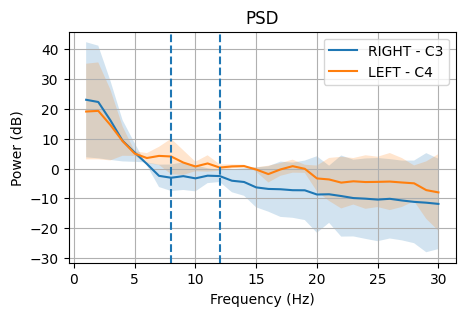

In [211]:
nperseg, noverlap = 1000, 100
plt.figure(figsize=(5, 3))
plot_psd_channel(epochs_1, sfreq=Fs, nperseg=nperseg, noverlap=noverlap, ch_idx=idx_C3, label="RIGHT - C3", fmin=1, fmax=30)
plot_psd_channel(epochs_2, sfreq=Fs, nperseg=nperseg, noverlap=noverlap, ch_idx=idx_C4, label="LEFT - C4", fmin=1, fmax=30)
plt.axvline(8, linestyle="--")
plt.axvline(12, linestyle="--")
plt.legend()
plt.show()

In [212]:
def plot_log_ratio_psd(ax, epochs_left, epochs_right, sfreq, nperseg, noverlap, ch_idx, ch_name, fmin=1, fmax=40):
    """
    log-ratio PSD: log(P_left / P_right)
    """

    def compute_mean_psd(epochs):
        psds = []
        for ep in epochs:
            freqs, psd = welch(
                ep[:, ch_idx],
                fs=sfreq,
                nperseg=nperseg,
                noverlap=noverlap
            )
            psds.append(psd)
        return freqs, np.mean(psds, axis=0)

    freqs, psd_left = compute_mean_psd(epochs_left)
    _, psd_right = compute_mean_psd(epochs_right)

    # защита от нулей
    eps = 1e-12
    log_ratio = np.log(psd_left + eps) - np.log(psd_right + eps)

    # ограничение диапазона
    mask = (freqs >= fmin) & (freqs <= fmax)

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.plot(freqs[mask], log_ratio[mask])

    ax.axhline(0, linestyle="--")
    ax.axvline(8, linestyle="--", alpha=0.5)
    ax.axvline(12, linestyle="--", alpha=0.5)
    ax.set_xticks(np.arange(fmin, fmax, 1))

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("log(P_left / P_right)")
    ax.set_title(f"Log-Ratio PSD (channel {ch_name})")
    ax.grid(True)

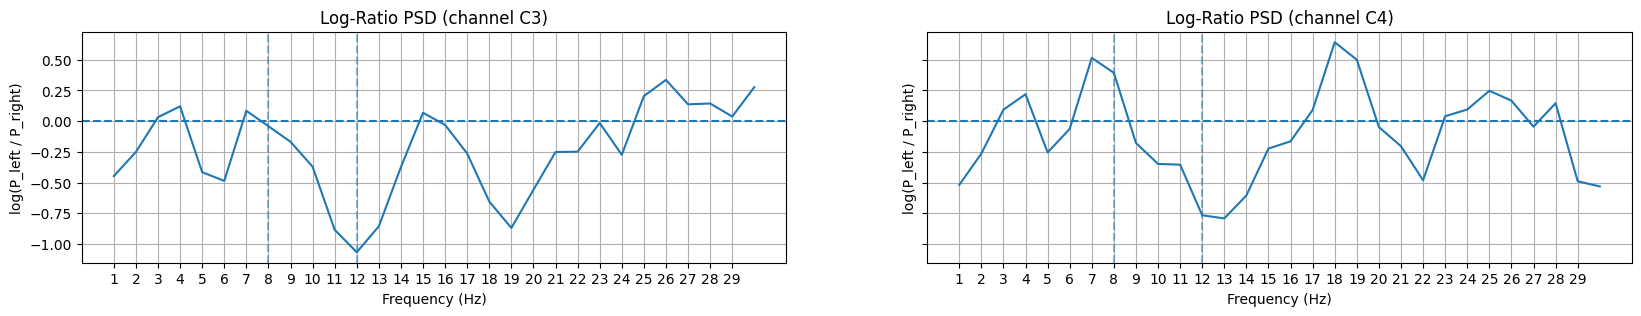

In [213]:
fig, ax = plt.subplots(1, 2, figsize=(20,3), sharey=True)
nperseg, noverlap = 1000, 100
plot_log_ratio_psd(ax[0], epochs_2, epochs_1, sfreq=Fs, nperseg=nperseg, noverlap=noverlap, ch_idx=idx_C3, ch_name="C3", fmin=1, fmax=30)
plot_log_ratio_psd(ax[1], epochs_2, epochs_1, sfreq=Fs, nperseg=nperseg, noverlap=noverlap, ch_idx=idx_C4, ch_name="C4", fmin=1, fmax=30)

In [231]:
band = [10, 12]
eeg_fb, _ = bandpass_filter(eeg_f, fs=Fs, low=band[0], high=band[1])

In [232]:
epochs_1_fb = slice_epochs(eeg_fb, idxs_right)        # right hand
epochs_2_fb = slice_epochs(eeg_fb, idxs_left)         # left hand

In [233]:
from scipy.signal import  hilbert
from scipy.signal import butter, filtfilt

def bandpass(data, sfreq, fmin, fmax, order=4):
    nyq = sfreq / 2
    b, a = butter(order, [fmin / nyq, fmax / nyq], btype="band")
    return filtfilt(b, a, data, axis=0)

def plot_erd(epochs, sfreq, ch_idx, tmin, baseline=(-1.0, 0.0), band=(8, 14), label=None):
    """
    ERD/ERS (% изменения мощности относительно baseline)

    epochs: [n_trials, samples, channels]
    tmin: время начала эпохи (в секундах)
    """

    n_trials, n_samples, _ = epochs.shape
    times = np.arange(n_samples) / sfreq + tmin

    # фильтрация
    data = np.array([ep[:, ch_idx] for ep in epochs])
    
    # мощность (amplitude^2)
    analytic = hilbert(data, axis=1)
    power = np.abs(analytic)**2  # мощность
    # print()
    
    # baseline
    baseline_mask = (times >= baseline[0]) & (times <= baseline[1])
    if not baseline_mask.any():
        raise ValueError("Baseline вне диапазона эпохи!")
    baseline_power = power[:, baseline_mask].mean(axis=1, keepdims=True)
    print("Baseline mean:", baseline_power.mean(), baseline_mask.shape)
    print("power mean:", power.mean(), power.shape)

    # ERD по trial
    erd = (power - baseline_power) / baseline_power * 100  # в процентах

    # усреднение по trial
    mean_erd = erd.mean(axis=0)
    std_erd = erd.std(axis=0)

    plt.figure(figsize=(8, 2))

    plt.plot(times, mean_erd, label=label)
    # plt.fill_between(
    #     times,
    #     mean_erd - std_erd,
    #     mean_erd + std_erd,
    #     alpha=0.2
    # )

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")  # cue

    plt.xlabel("Time (s)")
    plt.ylabel("ERD (%)")
    plt.title(f"ERD ({band[0]}–{band[1]} Hz), channel {ch_idx}")
    plt.grid(True)

    if label:
        plt.legend()
    # plt.ylim(-100, 100)
    plt.show()

Baseline mean: 0.5265512342910719 (3467,)
power mean: 1.834989236021143 (11, 3467)


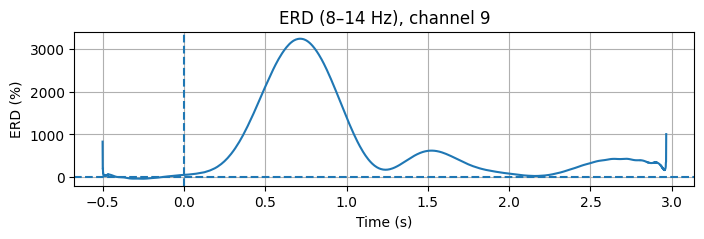

Baseline mean: 1.3113890593210955 (3483,)
power mean: 4.396368134821002 (7, 3483)


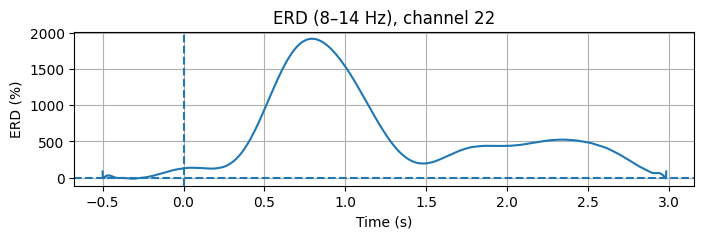

In [234]:
plot_erd(epochs_1_fb, sfreq=Fs, ch_idx=idx_C3, tmin=-start_shift/1000, baseline=(-start_shift/1000, -0.2), label=None)
plot_erd(epochs_2_fb, sfreq=Fs, ch_idx=idx_C4, tmin=-start_shift/1000, baseline=(-start_shift/1000, -0.2), label=None)

In [235]:
n = 250 // (1000 // Fs)
# epochs_1, epochs_2 = slice_epochs(eeg, idxs_right)[:, n+start_shift:-n:, :], slice_epochs(eeg, idxs_left)[:, n+start_shift:-n:, :]
# band = (8, 12)
# epochs_1_f = np.array([bandpass_filter(ep, fs=Fs, low=band[0], high=band[1])[0] for ep in epochs_1])
# epochs_2_f = np.array([bandpass_filter(ep, fs=Fs, low=band[0], high=band[1])[0] for ep in epochs_2])

zero-size array to reduction operation maximum which has no identity
zero-size array to reduction operation minimum which has no identity


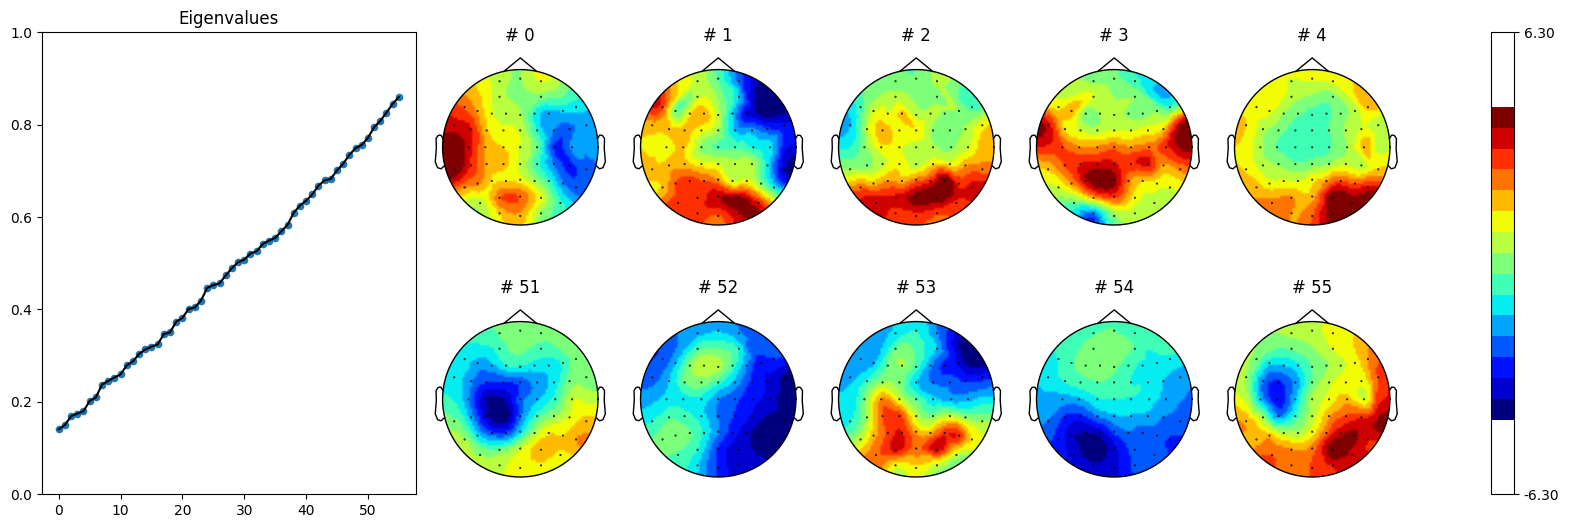

In [251]:
from src.analysis.CSP import compute_csp
from src.visualization.plot_csp_components import plot_10_csp_components

band = [8, 15]
eeg_fb, _ = bandpass_filter(eeg_f, fs=Fs, low=band[0], high=band[1])
n = 250 // (1000 // Fs)
epochs_1_fb = slice_epochs(eeg_fb, idxs_right)[:, n+start_shift:-n:, :]        # right hand
epochs_2_fb = slice_epochs(eeg_fb, idxs_left)[:, n+start_shift:-n:, :]         # left hand
projInverse, projForward, evals = compute_csp(epochs_1_fb, epochs_2_fb, robust=True)
fig = plot_10_csp_components(abs(evals), projForward, xy)

In [110]:
sel_comp = [0, 1, 55]

In [190]:
def apply_csp(epochs, W, sel_components=None):
    filter = W[:, sel_components] if sel_components is not None else W
    epochs_csp = np.array([
        ep @ filter for ep in epochs
    ])

    return epochs_csp

epochs_1_csp = apply_csp(epochs_1_fb, projInverse, sel_components=sel_comp)
epochs_2_csp = apply_csp(epochs_2_fb, projInverse, sel_components=sel_comp)

In [119]:
def csp_features(epochs_csp, eps=1e-10):
    """
    epochs: [n_epochs, samples, channels]
    """
    feats = []
    for ep in epochs_csp:
        var = np.var(ep, axis=0)
        var = var / (np.sum(var) + eps)   # нормализация
        feats.append(np.log(var + eps))   # защита от log(0)
    return np.array(feats)

X1 = csp_features(epochs_1_csp)
X2 = csp_features(epochs_2_csp)

X = np.concatenate([X1, X2], axis=0)
y = np.concatenate([np.ones(len(epochs_1_csp)), np.zeros(len(epochs_2_csp))])

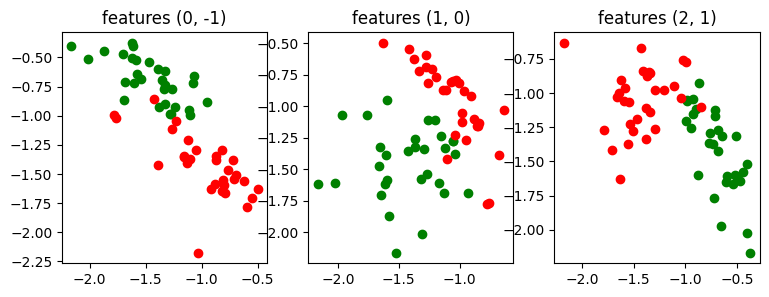

In [125]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for i in [0, 1, 2]:
    ax[i].scatter(X1[:, i], X1[:, i-1], color='green')
    ax[i].scatter(X2[:, i], X2[:, i-1], color='red')
    ax[i].set_title(f"features {i, i-1}")

In [130]:
classifier = LDA()
scores = cross_validate(classifier, X, y, cv=5, scoring=('accuracy', 'balanced_accuracy', 'f1'), return_train_score=True)
scores["test_balanced_accuracy"], scores["test_accuracy"]

(array([0.91666667, 0.91666667, 1.        , 0.91666667, 1.        ]),
 array([0.91666667, 0.91666667, 1.        , 0.91666667, 1.        ]))

In [147]:
n = 250 // (1000 // Fs)
epochs_1_fb = slice_epochs(eeg_fb, idxs_right)[:, n+start_shift:-n:, :]        # right hand
epochs_2_fb = slice_epochs(eeg_fb, idxs_left)[:, n+start_shift:-n:, :]         # left hand

In [160]:
def get_epoch(epochs_1, epochs_2, idx):
    if idx < len(epochs_1):
        return epochs_1[idx]
    else:
        return epochs_2[idx-len(epochs_1)]

In [ ]:
def train_classifier(epochs_1, epochs_2, sel_comp=[0, -1], clf=LDA()):
    projInverse, projForward, evals = compute_csp(epochs_1, epochs_2, robust=True)
    
    epochs_1_csp = apply_csp(epochs_1, projInverse, sel_components=sel_comp)
    epochs_2_csp = apply_csp(epochs_2, projInverse, sel_components=sel_comp)

    X1 = csp_features(epochs_1_csp)
    X2 = csp_features(epochs_2_csp)

    X = np.concatenate([X1, X2], axis=0)
    y = np.concatenate([np.ones(len(epochs_1_csp)), np.zeros(len(epochs_2_csp))])

    clf.fit(X, y)
    return projInverse, clf

def compute_metrics(y, y_pred):
    y = np.asarray(y)
    y_pred = np.asarray(y_pred)
    
    # confusion matrix: [[TN, FP],
    #                    [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    
    # базовые метрики
    acc = accuracy_score(y, y_pred)
    bal_acc = balanced_accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    # производные метрики
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # recall / sensitivity
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # specificity
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    
    return {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "f1": f1,
        "TPR": tpr,
        "TNR": tnr,
        "FNR": fnr,
        "FPR": fpr,
    }

def test_classifier(epochs_1, epochs_2, W, sel_comp, clf):
    epochs_1_csp = apply_csp(epochs_1, W, sel_components=sel_comp)
    epochs_2_csp = apply_csp(epochs_2, W, sel_components=sel_comp)

    X1 = csp_features(epochs_1_csp)
    X2 = csp_features(epochs_2_csp)

    X = np.concatenate([X1, X2], axis=0)
    y = np.concatenate([np.ones(len(epochs_1_csp)), np.zeros(len(epochs_2_csp))])

    y_pred = clf.predict(X)
    return y_pred, compute_metrics(y, y_pred)

In [ ]:
n_iter = 5 
skf = StratifiedKFold(n_splits=n_iter, shuffle=True, random_state=42)    # создаём k-fold
idxs = np.arange(len(epochs_1_fb) + len(epochs_2_fb))
y = np.array([1] * len(epochs_1_fb) + [0] * len(epochs_2_fb))
results = []
for train_idx, test_idx in skf.split(idxs, y):
    X_train, X_test = idxs[train_idx], idxs[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # TRAIN CLASSIFIER
    X_train_1 = X_train[y_train == 1]
    epochs_1_train = np.array([get_epoch(epochs_1_fb, epochs_2_fb, idx) for idx in X_train_1])  # right

    X_train_2 = X_train[y_train == 0] 
    epochs_2_train = np.array([get_epoch(epochs_1_fb, epochs_2_fb, idx) for idx in X_train_2])  # left
    
    W, clf = train_classifier(epochs_1_train, epochs_2_train, sel_comp=sel_comp, clf=LDA())

    # TEST CLASSIFIER
    X_test_1 = X_test[y_test == 1]
    epochs_1_test = np.array([get_epoch(epochs_1_fb, epochs_2_fb, idx) for idx in X_test_1])  # right

    X_test_2 = X_test[y_test == 0] 
    epochs_2_test = np.array([get_epoch(epochs_1_fb, epochs_2_fb, idx) for idx in X_test_2])  # left

    _, res = test_classifier(epochs_1_test, epochs_2_test, W, sel_comp, clf)
    results.append(res)

In [176]:
df_res = pd.DataFrame(results).round(2)
df_res.mean(axis=0)

accuracy             0.668
balanced_accuracy    0.668
f1                   0.712
TPR                  0.800
TNR                  0.532
FNR                  0.200
FPR                  0.468
dtype: float64

In [177]:
# final training
W, clf = train_classifier(epochs_1_fb, epochs_2_fb, sel_comp=sel_comp, clf=LDA())

In [203]:
folder = "03_23 Artem"
record = "05_game.hdf"
def test_on_game(filename, band, W, sel_comp, clf):
    path_filename= os.path.join(r"..\data\test", folder, record) 
    data, _ = load_h5df(path_filename)
    trigger = data[:, -1]
    trigger = ttl2binary(data[:, -1], bit_index=0)
    trigger = reverse_trigger(trigger)
    eeg = data[:, EEG_CHANNELS] * 1E6
    eeg_fb, _ = bandpass_filter(eeg, fs=Fs, low=band[0], high=band[1])
    idxs_rest, idxs_right, idxs_left = parse_events(trigger, window_size=200, start_shift=start_shift, end_shift=0)
    n = 250 // (1000 // Fs)
    epochs_1_fb = slice_epochs(eeg_fb, idxs_right)[:, n+start_shift:-n:, :]        # right hand
    epochs_2_fb = slice_epochs(eeg_fb, idxs_left)[:, n+start_shift:-n:, :]         # left hand
    
    epochs_1_csp = np.array([ep @ W for ep in epochs_1_fb])
    epochs_2_csp = np.array([ep @ W for ep in epochs_2_fb])
    
    X1 = csp_features(epochs_1_csp)
    X2 = csp_features(epochs_2_csp)

    X = np.concatenate([X1, X2], axis=0)
    y = np.concatenate([np.ones(len(epochs_1_csp)), np.zeros(len(epochs_2_csp))])

    y_pred = clf.predict(X)
    return y_pred, compute_metrics(y, y_pred)

In [204]:
test_on_game(record, band, W[:, sel_comp], None, clf)

(array([1., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0.,
        1.]),
 {'accuracy': 0.3888888888888889,
  'balanced_accuracy': 0.3701298701298701,
  'f1': 0.47619047619047616,
  'TPR': np.float64(0.45454545454545453),
  'TNR': np.float64(0.2857142857142857),
  'FNR': np.float64(0.5454545454545454),
  'FPR': np.float64(0.7142857142857143)})

In [183]:
W.shape

(56, 56)